In [2]:
import pandas as pd

df = pd.read_csv('/Users/Diane/Desktop/PSYCH 186B/project/reviews_Parasite_RT.csv')

df

,movie_title,tomatometer,popcornmeter,review_type,reviewer,publication,score,date,review_text
0,Parasite,99%,NaN,critic,Julian Singleton,Cinapse,NaN,Jul 12,A raucous rollercoaster of genre from sleek cr...
1,Parasite,99%,NaN,critic,Sharai Bohannon,A Nightmare On Fierce Street Podcast,5/5,Jun 23,Korean cinema is always that girl. Part of the...
2,Parasite,99%,NaN,critic,Emma Simmonds,Radio Times,5/5,08/30/2024,"It's a wonderfully sneaky film that, before yo..."
3,Parasite,99%,NaN,critic,Denise Pieniazek,Puesta en Escena (AR),9.5,08/15/2024,"Fundamentally, Parasite aims to make us reflec..."
4,Parasite,99%,NaN,critic,Diana Tuova,Spotlight on Film,5/5,07/30/2024,Parasite is both darkly hilarious and delightf...
...,...,...,...,...,...,...,...,...,...
95,Parasite,99%,NaN,audience,Joni,NaN,NaN,03/08/2020,Full of plottwists backed-up with a good story...
96,Parasite,99%,NaN,audience,andi p,NaN,NaN,03/08/2020,"Incredible film. Haunting, beautiful. Absolute..."
97,Parasite,99%,NaN,audience,Ellen K,NaN,NaN,03/07/2020,It was okay once I got used to reading the wor...
98,Parasite,99%,NaN,audience,Andrew L,NaN,NaN,03/07/2020,Amazing story. One of a kind.See MoreSee Less


In [4]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# preprocessing the data 

lex = pd.read_csv("/Users/Diane/Desktop/PSYCH 186B/project/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep='\t', names=['word', 'emotion', 'assoc'])

lex = lex[lex['assoc'] == 1]

emotion_map = lex.groupby('word')['emotion'].apply(list).to_dict()
print("Review dataset columns:", df.columns)

Review dataset columns: Index(['movie_title', 'tomatometer', 'popcornmeter', 'review_type', 'reviewer',
       'publication', 'score', 'date', 'review_text'],
      dtype='object')


[nltk_data] Downloading package stopwords to /Users/Diane/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


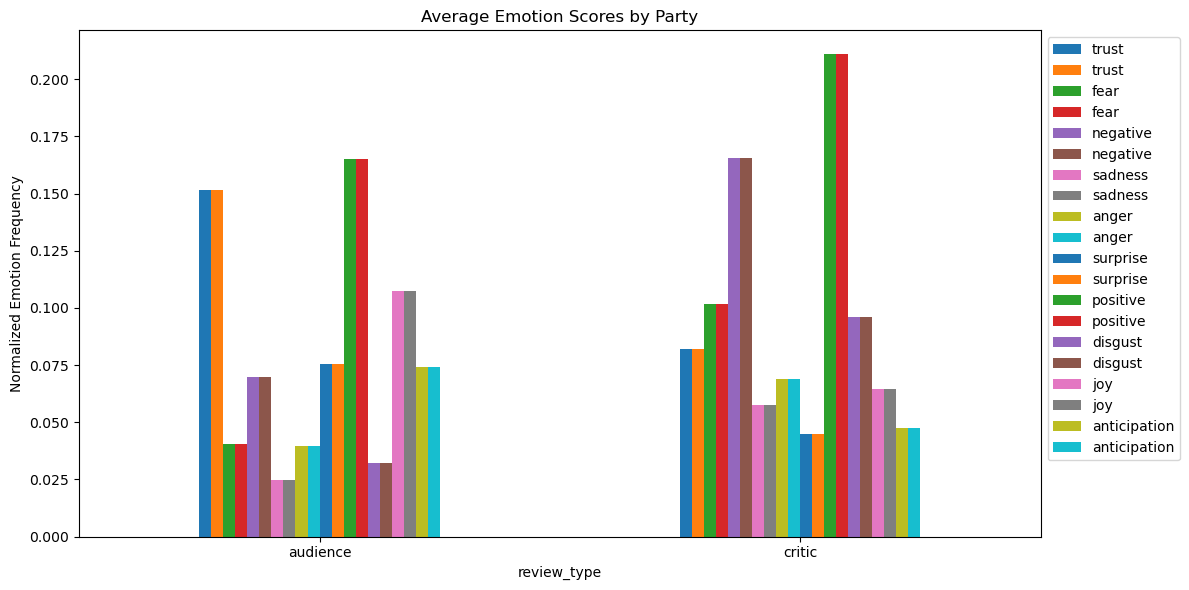

In [8]:
# define necessary functions 

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|[^a-z\s]", "", text)
    return [word for word in text.split() if word not in stop_words]

def get_emotions(text):
    words = simple_tokenizer(text)
    emotions = [emo for word in words for emo in emotion_map.get(word, [])]
    return Counter(emotions)

def normalize(counter):
    total = sum(counter.values())
    return {emotion: count / total for emotion, count in counter.items()} if total > 0 else {}

# apply functions 
df['emotion_counts'] = df['review_text'].apply(get_emotions)
df['emotion_normalized'] = df['emotion_counts'].apply(normalize)

# split into columns 
emotion_df = df['emotion_normalized'].apply(pd.Series).fillna(0)
df = pd.concat([df, emotion_df], axis=1)

# average by group 
party_col = 'review_type'
emotion_cols = lex['emotion'].unique().tolist()
grouped = df.groupby(party_col)[emotion_cols].mean()

# average counts plot
grouped.plot(kind='bar', figsize=(12, 6))
plt.title("Average Emotion Scores by Party")
plt.ylabel("Normalized Emotion Frequency")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()